In [1]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

Current working directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Files in current directory: ['exploratory_data_analysis.ipynb', 'explore_model_outputs.ipynb']


In [7]:
# --- 1. Imports ---
from src.data_cleaning import clean_data_pipeline
from src.feature_engineering import feature_engineering_pipeline
from src.modelling import run_gwr_pipeline
import matplotlib.pyplot as plt
import geopandas as gpd

# --- 2. Load your processed GeoDataFrame ---
#data = clean_data_pipeline()
# data = feature_engineering_pipeline(
#     data=data,
#     country_key="ken",
#     feature_keys=["police"],
#     unit_id_col="GID_2"
# )


# gdf = data['ken']['features']

# # --- 3. Run GWR pipeline ---
# gdf_gwr, gwr_results, bw = run_gwr_pipeline(
#     gdf,
#     y_var='log_conflict_rate',   # dependent variable (logged)
#     x_vars=['log_police_density'],        # independent variable(s)
#     standardize=True,                     # recommended
#     kernel='gaussian',                    # default kernel
#     auto_select_bw=True                   # let MGWR choose bandwidth
# )

# print(f"Selected bandwidth: {bw}")
# print(gwr_results.summary())


def run_country_gwr(
    data,
    country_key,
    y_var,
    x_vars,
    feature_keys,
    unit_id_col="GID_2"
):
    """
    Runs feature engineering and GWR for a single country.

    Parameters
    ----------
    data : dict
        Cleaned and loaded data
    country_key : str
        e.g. "ken", "eth"
    y_var : str
        Dependent variable column name (e.g. "log_conflict_rate")
    x_vars : list of str
        List of predictor column names (e.g. ["log_police_density", "log_schools_density"])
    feature_keys : list of str
        Keys to aggregate from data[country_key] (e.g. ["police", "schools", "hospitals"])
    unit_id_col : str
        Admin unit identifier, usually "GID_2"

    Returns
    -------
    gdf_gwr : GeoDataFrame (with GWR outputs added)
    gwr_results : mgwr.model.GWRResults object
    bw : int
        Selected bandwidth
    """

    # 1. Feature engineering
    data = feature_engineering_pipeline(
        data=data,
        country_key=country_key,
        feature_keys=feature_keys,
        unit_id_col=unit_id_col
    )

    gdf = data[country_key]["features"].copy()

    print(gdf.columns)

    # 2. Check y_var and x_vars exist
    missing = [col for col in [y_var] + x_vars if col not in gdf.columns]
    if missing:
        raise ValueError(f"Missing required columns in gdf: {missing}")

    # 3. Drop rows with NA in y or any x
    gdf = gdf.dropna(subset=[y_var] + x_vars).copy()

    print(f"\n===== Running GWR for {country_key.upper()} =====")
    print(f"Dependent variable: {y_var}")
    print(f"Predictors: {x_vars}")
    print(f"Feature keys used: {feature_keys}")
    print(f"Remaining observations: {len(gdf)}")

    # 4. Run GWR pipeline
    gdf_gwr, gwr_results, bw = run_gwr_pipeline(
        gdf,
        y_var=y_var,
        x_vars=x_vars,
        standardize=True,
        kernel='gaussian',
        auto_select_bw=True
    )

    # 5. Print summary
    print(f"\nSelected bandwidth: {bw}")
    print(gwr_results.summary())

    return gdf_gwr, gwr_results, bw


In [8]:
data = clean_data_pipeline()

# Kenya
gdf_gwr_ken, gwr_results_ken, bw_ken = run_country_gwr(
    data=data,
    country_key="ken",
    y_var="log_conflict_rate",
    x_vars=["log_police_density", "log_hospitals_density"],
    feature_keys=["police", "hospitals"],
    unit_id_col="GID_2"
)

# Ethiopia
gdf_gwr_eth, gwr_results_eth, bw_eth = run_country_gwr(
    data=data,
    country_key="eth",
    y_var="log_conflict_rate",
    x_vars=["log_police_density", "log_hospitals_density"],
    feature_keys=["police", "hospitals"],
    unit_id_col="GID_2"  # assuming GID_2 exists in ETH as well
)


Starting data cleaning pipeline...
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_hospitals.parquet
Replaced 226794771 missing values (-99999.0) with 0 in eth - population
Replaced 100583464 missing values (-99999.0) with 0 in ken - population
Data cleaning complete.
Starting feature engineering pipeline for: ken
  - Spatially joining ACLED events to admin units...
  - Spatially joining police to admin units...
  - Spatially joining hospitals to admin units...
  -> Aggregation complete: conflict_count + feature counts added.
Adding population from raster to admin units...
  - Population raster CRS: EPSG:32637
  - Running zonal statistics (sum of population per unit). This may take a moment.

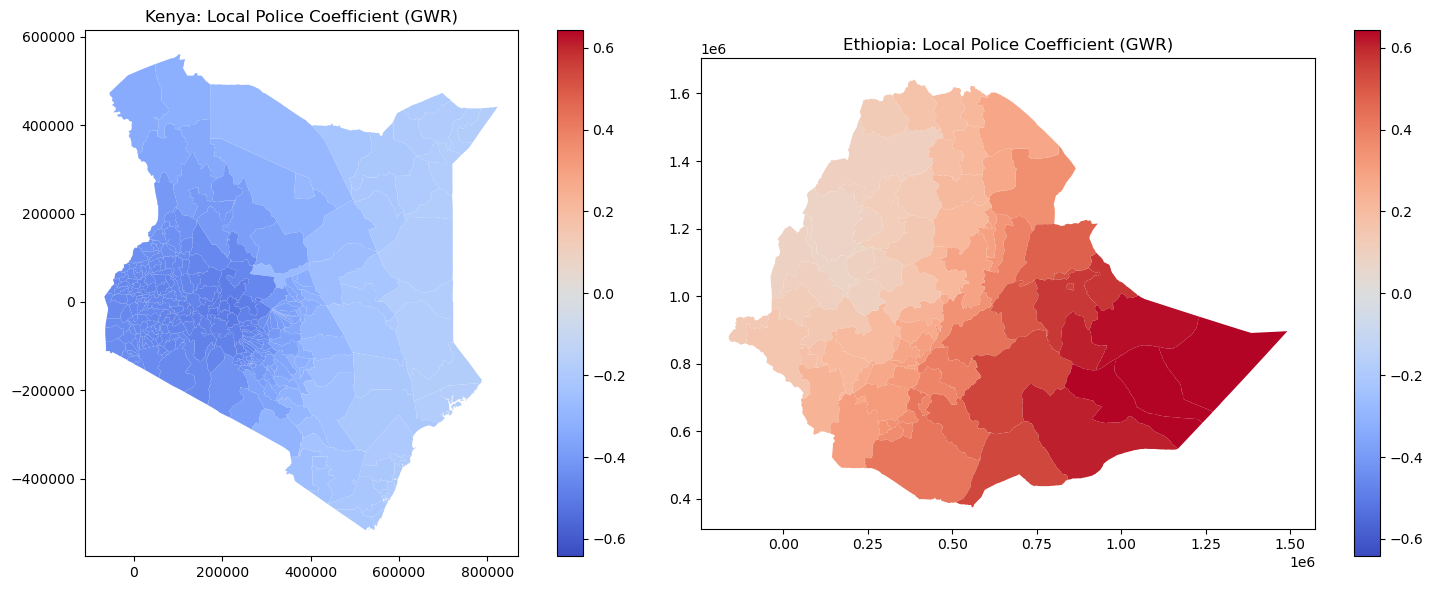

In [10]:
import matplotlib.pyplot as plt

coef_col = 'gwr_log_hospitals_density_coef'

# 1. Compute symmetric scale across BOTH countries
min_val = min(gdf_gwr_ken[coef_col].min(), gdf_gwr_eth[coef_col].min())
max_val = max(gdf_gwr_ken[coef_col].max(), gdf_gwr_eth[coef_col].max())
max_abs = max(abs(min_val), abs(max_val))

# 2. Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kenya
gdf_gwr_ken.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Kenya: Local Police Coefficient (GWR)")

# Ethiopia
gdf_gwr_eth.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Ethiopia: Local Police Coefficient (GWR)")

plt.tight_layout()
plt.show()


In [5]:
gdf_gwr_ken.columns

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry', 'conflict_count', 'police_count', 'population', 'area_km2',
       'conflict_rate_per_100k', 'police_per_10k', 'log_conflict_rate',
       'log_police_density', 'gwr_intercept', 'gwr_log_police_density_coef',
       'gwr_gwr_pred', 'gwr_gwr_resid', 'gwr_local_R2'],
      dtype='object')

<Figure size 800x600 with 0 Axes>

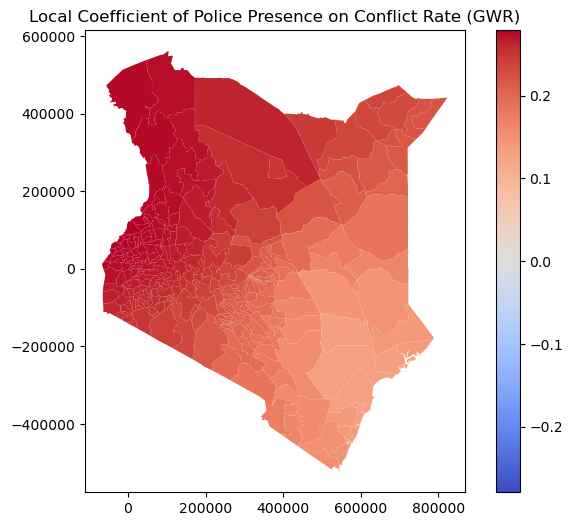

In [6]:
plt.figure(figsize=(8, 6))

# Calculate symmetric bounds around 0
max_abs_value = max(abs(gdf_gwr_ken['gwr_log_police_density_coef'].min()), 
                    abs(gdf_gwr_ken['gwr_log_police_density_coef'].max()))

gdf_gwr_ken.plot(column='gwr_log_police_density_coef',
             legend=True,
             cmap='coolwarm',
             figsize=(8,6),
             vmin=-max_abs_value,
             vmax=max_abs_value)
plt.title('Local Coefficient of Police Presence on Conflict Rate (GWR)')
plt.show()


<Figure size 800x600 with 0 Axes>

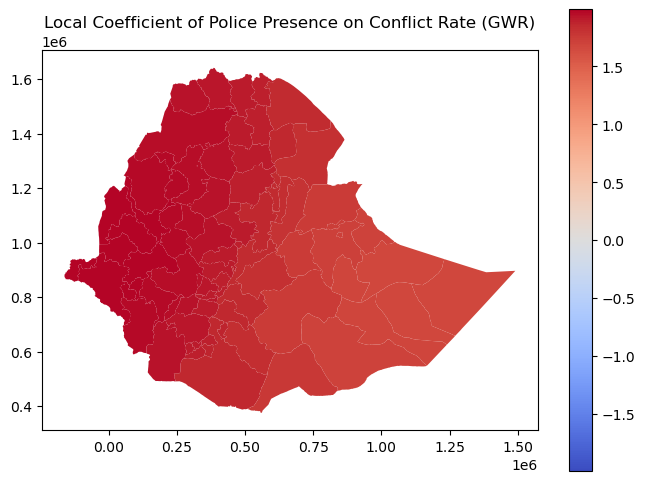

In [7]:
plt.figure(figsize=(8, 6))

# Calculate symmetric bounds around 0
max_abs_value = max(abs(gdf_gwr_eth['gwr_log_police_density_coef'].min()), 
                    abs(gdf_gwr_eth['gwr_log_police_density_coef'].max()))

gdf_gwr_eth.plot(column='gwr_log_police_density_coef',
             legend=True,
             cmap='coolwarm',
             figsize=(8,6),
             vmin=-max_abs_value,
             vmax=max_abs_value)
plt.title('Local Coefficient of Police Presence on Conflict Rate (GWR)')
plt.show()

<Figure size 800x600 with 0 Axes>

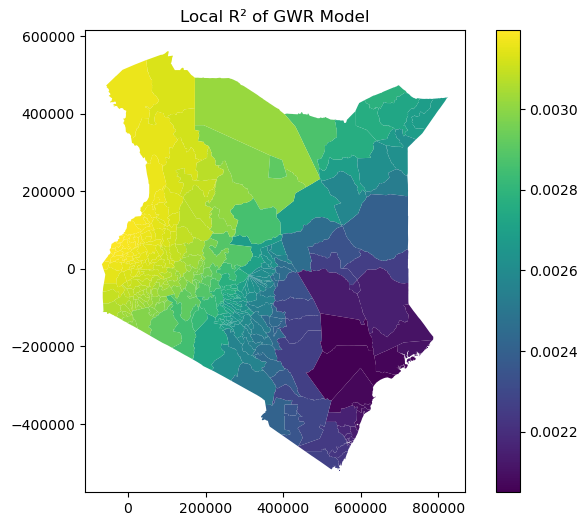

In [9]:
plt.figure(figsize=(8, 6))
gdf_gwr.plot(column='gwr_local_R2',
             legend=True,
             cmap='viridis',
             figsize=(8,6))
plt.title('Local R² of GWR Model')
plt.show()


<Figure size 800x600 with 0 Axes>

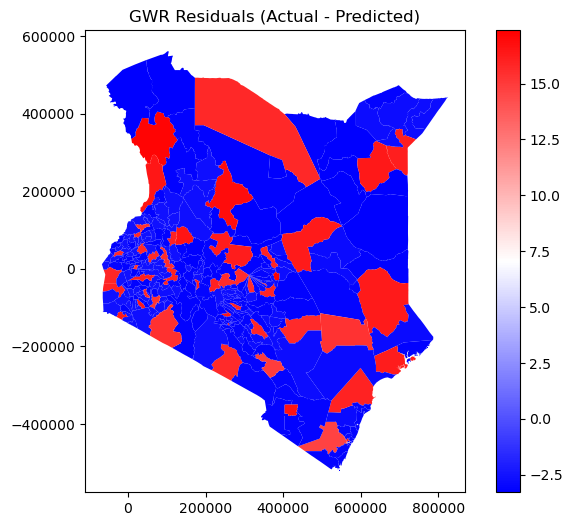

In [10]:
plt.figure(figsize=(8, 6))
gdf_gwr.plot(column='gwr_gwr_resid',
             legend=True,
             cmap='bwr',
             figsize=(8,6))
plt.title('GWR Residuals (Actual - Predicted)')
plt.show()


In [11]:
import numpy as np
import statsmodels.api as sm

# 1. Extract variables
y = gdf["log_conflict_rate"]  # dependent variable
X = gdf[["log_police_density"]]  # independent variable

# 2. Add constant
X_const = sm.add_constant(X)

# 3. Fit OLS
ols_model = sm.OLS(y, X_const).fit()

# 4. Extract OLS AIC (statsmodels gives AIC, not AICc)
ols_aic = ols_model.aic
n = len(y)
k = len(ols_model.params)  # number of parameters (including intercept)

# 5. Compute AICc manually
ols_aicc = ols_aic + (2 * k * (k + 1)) / (n - k - 1)

print(f"OLS AIC:  {ols_aic:.3f}")
print(f"OLS AICc: {ols_aicc:.3f}")


OLS AIC:  2013.221
OLS AICc: 2013.262


In [12]:
gwr_aicc = gwr_results.aicc
print(f"GWR AICc: {gwr_aicc:.3f}")


GWR AICc: 2015.317


In [13]:
print(f"OLS AICc: {ols_aicc:.3f}")
print(f"GWR AICc: {gwr_aicc:.3f}")
print(f"Difference: {ols_aicc - gwr_aicc:.3f}")


OLS AICc: 2013.262
GWR AICc: 2015.317
Difference: -2.055
